# 1. Algorithm (DONT CHANGE)

### Libraries

In [1]:
import GA
import config
import qfm_lib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from math import comb
import glob

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    roc_auc_score, f1_score, balanced_accuracy_score,
    precision_score, recall_score, accuracy_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_regression
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import matthews_corrcoef, confusion_matrix
import shap
import dcor
import seaborn as sns
from scipy.spatial.distance import pdist, squareform

from itertools import combinations
from collections import Counter

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator

from qfm_lib import *

from sklearn.cluster import SpectralClustering

### Hyperparameters

In [2]:
service = QiskitRuntimeService()
service.backends()
real_backend = service.backend("ibm_pittsburgh")

management.get:WARNING:2026-02-17 00:28:21,039: Loading default saved account


In [29]:
SIMULATION = False # for QPU use false
FAKEBACKEND = False # for QPU use false

USE_FIXED_PERM = False # for QPU use false
USE_FIXED_PHYS_NODES = False # for QPU use false

SEED = 42

OPTIMIZATION_LVL = 3
RESILIENCE_LVL = 1

m = 1
k_max = 2
q_ks_for_aug = [1, 2]  # which ks enter X_aug
tau = 0.005
l = 1  # order of approximation of CD terms
k_top = 50

### Dataset manipulation

In [4]:
def load_dataset(dataset_dir):
    df = pd.read_csv(dataset_dir)
    df['Class'] = df['Class'].map({'NonToxic': 1,'Toxic': 0})
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values
    return X, y

# feature reduction to match number of qubits in qpu
def reduce_features(X, y, n_features):
    if X.shape[1] <= n_features:
        return X
    else:
        mi = mutual_info_classif(X, y, n_neighbors=5, discrete_features=False, random_state=SEED)
    top_indices = np.argsort(mi)[-n_features:]
    return X[:, top_indices]


def data_preprocessing(X_train, X_test):
    scaler = StandardScaler() # Rescale the data using z-score: (x - μ (mean))/μ (standard deviation)
    X_tr = scaler.fit_transform(X_train)
    Xte = scaler.transform(X_test)
    return X_tr, Xte

def data_preprocessing_all(X):
    scaler = StandardScaler() # Rescale the data using z-score: (x - μ (mean))/μ (standard deviation)
    X_scaled = scaler.fit_transform(X)
    return X_scaled

### Estimator

In [30]:
def setup_estimator_backend():
    if SIMULATION:
        if FAKEBACKEND:
            backend = AerSimulator.from_backend(real_backend)
            backend.set_options(method="density_matrix", device="CPU", seed_simulator=SEED)
        else:
            backend = AerSimulator(method="statevector", device="CPU")
            backend.options.seed_simulator = SEED
            backend.options.seed_transpiler = SEED        
    else:
        backend = real_backend    
        backend.options.seed_transpiler = SEED

    estimator = Estimator(
        backend,
        options={
            "default_shots": 4096,
            "resilience_level": RESILIENCE_LVL,
            # "resilience": {"measure_mitigation": True},
            # "twirling": {"enable_gates": True, "num_randomizations": 4},
        },
    )
    return estimator, backend

### J_ij calculation

 - Mutual information calculation

for now use just 2-body terms

In [6]:
def calculate_MI_matrix(X):
    num_features = X.shape[1]
    MI_b = np.zeros((num_features, num_features))
    for i in range(num_features):
        for j in range(i+1, num_features):
            MI_b[i, j] = mutual_info_regression(
                X[:, [i]],
                X[:, j],
                n_neighbors=5,
                random_state=SEED,
            )[0]
            MI_b[j, i] = MI_b[i, j]

    MI_norm = MI_b / (MI_b.max() + 1e-12)
    return MI_norm

def calculate_J_matrix(X):
    MI_matrix = calculate_MI_matrix(X)
    j = MI_matrix.copy()
    rho_thr = 0.0
    j[j < rho_thr] = 0.0
    np.fill_diagonal(j, 0.0)
    return j

 - Pearson correlation coefficient calculation

In [7]:
def calculate_J_matrix_pearson(X):
    # Pearson correlation matrix
    J = np.corrcoef(X, rowvar=False)

    # Zero diagonal
    np.fill_diagonal(J, 0.0)

    return J

 - Distance correliation calculation

In [8]:
def calculate_dcor_matrix(X):
    num_features = X.shape[1]
    dcor_matrix = np.zeros((num_features, num_features))
    
    for i in range(num_features):
        for j in range(i+1, num_features):
            # Compute distance correlation between feature i and feature j
            dcor_matrix[i, j] = dcor.distance_correlation(X[:, i], X[:, j])
            dcor_matrix[j, i] = dcor_matrix[i, j]  # symmetric

    # Normalize to [0, 1]
    #dcor_matrix_norm = dcor_matrix / (dcor_matrix.max() + 1e-12)
    return dcor_matrix

def calculate_J_matrix_dcor(X):
    dcor_matrix = calculate_dcor_matrix(X)
    j = dcor_matrix.copy()
    rho_thr = 0.0  # threshold
    j[j < rho_thr] = 0.0
    np.fill_diagonal(j, 0.0)
    return j

 - Hilbert-Schmidt Independence Criterion

In [9]:
def rbf_kernel(x, sigma=None):
    """
    Compute Gaussian (RBF) kernel matrix for 1D array x
    """
    x = x.reshape(-1, 1)
    pairwise_sq_dists = squareform(pdist(x, 'sqeuclidean'))
    
    if sigma is None:
        # median heuristic for bandwidth
        sigma = np.median(pairwise_sq_dists)
        if sigma == 0:
            sigma = 1.0

    K = np.exp(-pairwise_sq_dists / (2 * sigma))
    return K

def hsic(X, Y, sigma_X=None, sigma_Y=None):
    """
    Compute normalized Hilbert-Schmidt Independence Criterion (HSIC) for 1D arrays
    Returns scalar value in [0,1] (normalized)
    """
    n = X.shape[0]
    K = rbf_kernel(X, sigma=sigma_X)
    L = rbf_kernel(Y, sigma=sigma_Y)
    
    # Center the kernel matrices
    H = np.eye(n) - np.ones((n, n)) / n
    Kc = H @ K @ H
    Lc = H @ L @ H
    
    hsic_val = np.trace(Kc @ Lc) / (n - 1)**2
    return hsic_val

def calculate_hsic_matrix(X):
    """
    Compute HSIC matrix for all feature pairs
    """
    num_features = X.shape[1]
    hsic_matrix = np.zeros((num_features, num_features))
    
    for i in range(num_features):
        for j in range(i+1, num_features):
            hsic_val = hsic(X[:, i], X[:, j])
            hsic_matrix[i, j] = hsic_val
            hsic_matrix[j, i] = hsic_val  # symmetric

    return hsic_matrix


def calculate_J_matrix_hsic(X):
    hsic_matrix = calculate_hsic_matrix(X)
    np.fill_diagonal(hsic_matrix, 0.0)
    return hsic_matrix

 - sanity check: visualisation of J_matrix with different methods

Dataset loaded successfully! with shape: (171, 1203)
Reduced shape: (171, 10)


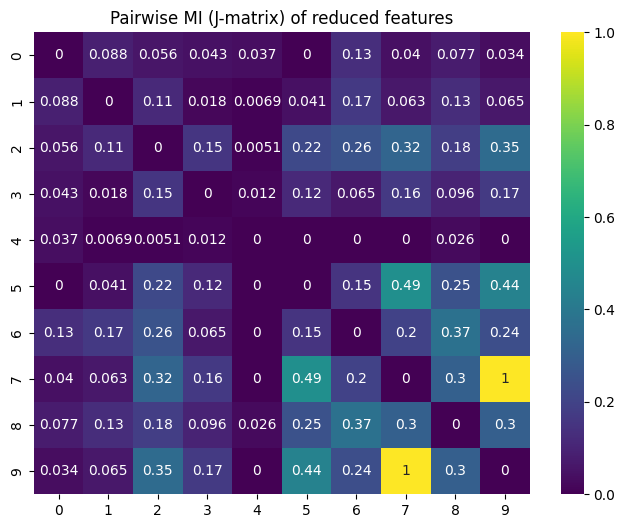

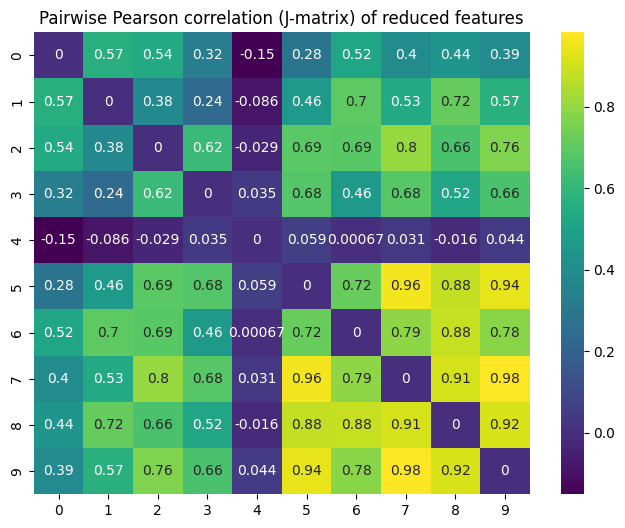

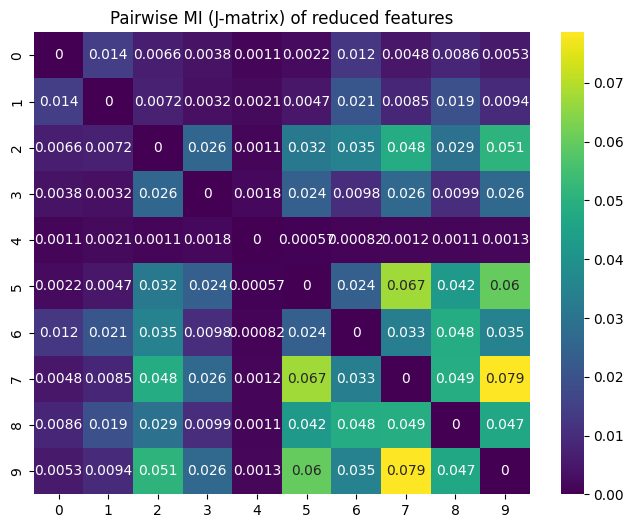

In [10]:
path = "data.csv"
X_full, y_full = load_dataset(path)
if X_full is not None and y_full is not None:
    print("Dataset loaded successfully! with shape:", X_full.shape)

n_features = 10
X_reduced = reduce_features(X_full, y_full, n_features)
print("Reduced shape:", X_reduced.shape)

X_scaled = data_preprocessing_all(X_reduced)

J_matrix = calculate_J_matrix(X_scaled)
plt.figure(figsize=(8,6))
sns.heatmap(J_matrix, annot=True, cmap='viridis')
plt.title("Pairwise MI (J-matrix) of reduced features")
plt.show()

J_matrix = calculate_J_matrix_pearson(X_scaled)
plt.figure(figsize=(8,6))
sns.heatmap(J_matrix, annot=True, cmap='viridis')
plt.title("Pairwise Pearson correlation (J-matrix) of reduced features")
plt.show()
#J_matrix = calculate_J_matrix_dcor(X_scaled)
J_matrix = calculate_J_matrix_hsic(X_scaled)
#print("J-matrix shape:", J_matrix.shape)
#print(J_matrix)

plt.figure(figsize=(8,6))
sns.heatmap(J_matrix, annot=True, cmap='viridis')
plt.title("Pairwise MI (J-matrix) of reduced features")
plt.show()

### Quantum features creation

In [11]:
def compute_quantum_features(X, base_folder):
    X = data_preprocessing_all(X)
    n_b = X.shape[1]
    J = calculate_J_matrix(X)
    #J = calculate_J_matrix_dcor(X)
    #J = calculate_J_matrix_hsic(X)
    estimator, backend = setup_estimator_backend()

    if (not SIMULATION) or FAKEBACKEND:
        cm = backend.coupling_map
        coupling_edges = cm.get_edges()
        target = backend.target

        for gname in ["ecr", "cz", "cx"]:
            if gname in target.operation_names:
                twoq_gate = gname
                break
        else:
            raise RuntimeError("I couldn't find ecr/cz/cx in backend.target, see target.operation_names")

        edge_cost = {}
        for (u, v) in coupling_edges:
            props = target[twoq_gate].get((u, v)) or target[twoq_gate].get((v, u))
            if props is not None and props.error is not None:
                edge_cost[(u, v)] = float(props.error)
            else:
                edge_cost[(u, v)] = 1.0

        phys_nodes = GA.pick_connected_subset_greedy(n_b, coupling_edges, edge_cost)

        with open(f"{base_folder}/phys_nodes.json", "w", encoding="utf-8") as f: 
            json.dump(phys_nodes, f)

        
        # selects a physical subgraph of size n_b in a "greedy" manner for the smallest error.
        if USE_FIXED_PHYS_NODES:
            with open("phys_nodes.json", "r", encoding="utf-8") as f:
                phys_nodes = json.load(f)
        else:
            phys_nodes = GA.pick_connected_subset_greedy(n_b, coupling_edges, edge_cost)

            with open(f"{base_folder}/phys_nodes.json", "w", encoding="utf-8") as f:
                json.dump(phys_nodes, f)

        phys_set = set(phys_nodes)
        phys_to_log = {p: i for i, p in enumerate(phys_nodes)}

        edges_log = []
        edge_weight = {}
        for (u, v) in coupling_edges:
            if u in phys_set and v in phys_set:
                i, j = phys_to_log[u], phys_to_log[v]
                edges_log.append((i, j))
                err = edge_cost.get((u, v), edge_cost.get((v, u), 1.0))
                edge_weight[(i, j)] = max(1e-6, 1.0 - err)

        # GA to map features -> logical qubits:
        # perm: the original classical feature perm[i] goes to the logical qubit i ->
        # serves to optimize embedding: which classical feature should go to which node (qubit)
        # in order to prioritize as neighbors those that have the largest Jij and smallest edge error.

        if USE_FIXED_PERM:
            with open("perm.json", "r", encoding="utf-8") as f:
                perm = json.load(f)
        else:
            perm, best_fit = GA.ga_assignment(
                J,
                edges_log,
                edge_weight=edge_weight,
                pop_size=80,
                ngen=300,
                k_tourn=3,
                elite_k=5,
                seed=SEED,
            )

            with open(f"{base_folder}/perm.json", "w", encoding="utf-8") as f:
                json.dump(perm, f)

        print("Final mapping of logical qubits to physical qubits:", phys_nodes)
        print("Order of features in encoding:", perm)

        J_dict = {}
        for (i, j) in edges_log:
            Jij = J[perm[i], perm[j]]
            if Jij > 0:
                J_dict[(i, j)] = Jij
        
        print("Number of active 2-local interactions:", len(J_dict))

        # Rotate the quantum map once (all 171 lines)
        Xq_all_raw, pairs_2q = build_quantum_features_all(
            X,
            J_dict,
            perm,
            phys_nodes,
            tau,
            m,
            backend,
            estimator,
            simulation=SIMULATION,
        )
    else:
        n = J.shape[0]
        J_dict = {}

        # only top part (i<j)
        for i in range(n):
            for j in range(i + 1, n):
                Jij = float(J[i, j])
                if Jij > 0.0:
                    J_dict[(i, j)] = Jij

        print("Number of active 2-local interactions:", len(J_dict))

        Xq_all_raw, pairs_2q = build_quantum_features_all_ideal(
            X,
            J_dict,
            tau,
            m,
            estimator,
            backend=None,
        )
        
    print('Quantum features successfully generated!')
    return Xq_all_raw, pairs_2q


 - same code as in previous cell, just ends with job submitted so you dont have to wait for results

In [27]:
def compute_quantum_features_just_job_submitted(X, base_folder):
    X = data_preprocessing_all(X)
    n_b = X.shape[1]
    J = calculate_J_matrix(X)
    #J = calculate_J_matrix_pearson(X)
    #J = calculate_J_matrix_hsic(X)
    estimator, backend = setup_estimator_backend()

    cm = backend.coupling_map
    coupling_edges = cm.get_edges()
    target = backend.target

    for gname in ["ecr", "cz", "cx"]:
        if gname in target.operation_names:
            twoq_gate = gname
            break
    else:
        raise RuntimeError("I couldn't find ecr/cz/cx in backend.target, see target.operation_names")

    edge_cost = {}
    for (u, v) in coupling_edges:
        props = target[twoq_gate].get((u, v)) or target[twoq_gate].get((v, u))
        if props is not None and props.error is not None:
            edge_cost[(u, v)] = float(props.error)
        else:
            edge_cost[(u, v)] = 1.0

    phys_nodes = GA.pick_connected_subset_greedy(n_b, coupling_edges, edge_cost)

    with open(f"{base_folder}/phys_nodes.json", "w", encoding="utf-8") as f: 
        json.dump(phys_nodes, f)

    
    # selects a physical subgraph of size n_b in a "greedy" manner for the smallest error.
    if USE_FIXED_PHYS_NODES:
        with open("phys_nodes.json", "r", encoding="utf-8") as f:
            phys_nodes = json.load(f)
    else:
        phys_nodes = GA.pick_connected_subset_greedy(n_b, coupling_edges, edge_cost)

        with open(f"{base_folder}/phys_nodes.json", "w", encoding="utf-8") as f:
            json.dump(phys_nodes, f)

    phys_set = set(phys_nodes)
    phys_to_log = {p: i for i, p in enumerate(phys_nodes)}

    edges_log = []
    edge_weight = {}
    for (u, v) in coupling_edges:
        if u in phys_set and v in phys_set:
            i, j = phys_to_log[u], phys_to_log[v]
            edges_log.append((i, j))
            err = edge_cost.get((u, v), edge_cost.get((v, u), 1.0))
            edge_weight[(i, j)] = max(1e-6, 1.0 - err)

    # GA to map features -> logical qubits:
    # perm: the original classical feature perm[i] goes to the logical qubit i ->
    # serves to optimize embedding: which classical feature should go to which node (qubit)
    # in order to prioritize as neighbors those that have the largest Jij and smallest edge error.

    if USE_FIXED_PERM:
        with open("perm.json", "r", encoding="utf-8") as f:
            perm = json.load(f)
    else:
        perm, best_fit = GA.ga_assignment(
            J,
            edges_log,
            edge_weight=edge_weight,
            pop_size=80,
            ngen=300,
            k_tourn=3,
            elite_k=5,
            seed=SEED,
        )

        with open(f"{base_folder}/perm.json", "w", encoding="utf-8") as f:
            json.dump(perm, f)

    print("Final mapping of logical qubits to physical qubits:", phys_nodes)
    print("Order of features in encoding:", perm)

    J_dict = {}
    for (i, j) in edges_log:
        Jij = J[perm[i], perm[j]]
        if Jij > 0:
            J_dict[(i, j)] = Jij
    
    print("Number of active 2-local interactions:", len(J_dict))

    # Rotate the quantum map once (all 171 lines)
    """
    Xq_all_raw, pairs_2q = build_quantum_features_all(
        X,
        J_dict,
        perm,
        phys_nodes,
        tau,
        m,
        backend,
        estimator,
        simulation=SIMULATION,
    )
    """
    job_id, pairs_2q = build_quantum_features_all_job(
        X,
        J_dict,
        perm,
        phys_nodes,
        tau,
        m,
        backend,
        estimator,
        optimization_lvl=OPTIMIZATION_LVL,
        simulation=SIMULATION,
    )
        
    return job_id, pairs_2q

### Saving quantum features into file

In [13]:
def save_quantum_features_and_pairs(X_c, y, X_q, pairs_2q, base_folder):
    X_c = data_preprocessing_all(X_c)
    num_features = X_c.shape[1]

    base_name = f"T_{tau}_m_{m}_kmax{k_max}_rescaled_{num_features}"

    q_path = f"{base_folder}/qfeatures_all_{base_name}.npy"
    pairs_path = f"{base_folder}/pairs_2q.json"

    np.save(q_path, X_q)

    # JSON-safe serialization
    pairs_2q_json = [list(p) for p in pairs_2q]
    with open(pairs_path, "w") as f:
        json.dump(pairs_2q_json, f)

    print("Saved quantum features in:", base_folder)



In [14]:
def save_quantum_features(X_c, X_q, base_folder):
    X_c = data_preprocessing_all(X_c)
    num_features = X_c.shape[1]

    base_name = f"T_{tau}_m_{m}_kmax{k_max}_rescaled_{num_features}"

    q_path = f"{base_folder}/qfeatures_all_{base_name}.npy"
    np.save(q_path, X_q)

### Saving job id into file

In [15]:
def save_job_id_and_pairs(job_id, pairs_2q, base_folder):
    job_path = f"{base_folder}/job_id.txt"
    with open(job_path, "w") as f:
        f.write(str(job_id))
    print("Saved job ID in:", job_path)

    pairs_path = f"{base_folder}/pairs_2q.json"
    with open(pairs_path, "w") as f:
        json.dump(pairs_2q, f)
    print("Saved 2-qubit pairs in:", pairs_path)

### Loading results from job id

In [17]:
def results_from_job_id(job_id):
    job = service.job(job_id)
    result = job.result()[0]
    evs = np.asarray(result.data.evs, dtype=float)

    # features per row (N_samples, n_obs)
    Xq_all = evs.T

    return Xq_all


### Loading quantum features from file

In [18]:
def load_quantum_features(base_folder, num_features):
    base_name = f"T_{tau}_m_{m}_kmax{k_max}_rescaled_{num_features}"

    q_path = f"{base_folder}/qfeatures_all_{base_name}.npy"
    pairs_path = f"{base_folder}/pairs_2q.json"

    Xq_all_raw = np.load(q_path)

    with open(pairs_path, "r") as f:
        pairs_2q = json.load(f)

    # convert back to tuples
    pairs_2q = [tuple(p) for p in pairs_2q]

    print("Loaded quantum features from:", base_folder)
    return Xq_all_raw, pairs_2q


### Cross-validation

In [46]:
def init_metrics_dict():
    return {
        "AUC": [],
        "F1 Macro": [],
        "Precision Macro": [],
        "Recall Macro": [],
        "Accuracy": [],
        "MCC": [],
    }

def update_metrics(metrics_dict, y_test, y_pred, y_proba):
    metrics_dict["AUC"].append(roc_auc_score(y_test, y_proba))
    metrics_dict["F1 Macro"].append(f1_score(y_test, y_pred, average="macro"))
    metrics_dict["Precision Macro"].append(precision_score(y_test, y_pred, average="macro", zero_division=0))
    metrics_dict["Recall Macro"].append(recall_score(y_test, y_pred, average="macro"))
    metrics_dict["Accuracy"].append(accuracy_score(y_test, y_pred))
    metrics_dict["MCC"].append(matthews_corrcoef(y_test, y_pred))

def median_metrics(metrics_dict):
    return {k: np.median(v) for k, v in metrics_dict.items()}

def cross_validate_model(X_c, y, base_folder, classifier, n_splits=5, n_repeats=5):
    qc_rskf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=SEED)
    
    # Initialize metrics
    all_metrics = {}
    model_names = ["Classical_orig"] + [f"Q_{k}body" for k in range(1, k_max + 1)] + ["SHAP50"]
    COLS = ["AUC", "F1 Macro", "Precision Macro", "Recall Macro", "Accuracy", "MCC"]
    for m in model_names:
        all_metrics[m] = {c: [] for c in COLS}
    
    shap_rankings = []

    conf_matrices = {m: [] for m in model_names}

    # Classical features
    X_cl_all = data_preprocessing_all(X_c)
    n_samples, n_cl = X_cl_all.shape

    # Quantum features
    Xq_all_raw, pairs_2q = load_quantum_features(base_folder, n_cl)
    n_q_samples, n_q_feats = Xq_all_raw.shape

    n1 = X_cl_all.shape[1]
    n2 = n_q_feats - n1

    # Feature names
    cl_names = [f"cl_{j}" for j in range(n_cl)]
    q1_names = [f"q1_z_{i}" for i in range(n1)]
    q2_names = [f"q2_z_{i}_{j}" for (i, j) in pairs_2q] if n2 > 0 else []

    q_names_by_k_global = {1: q1_names}
    if k_max >= 2 and n2 > 0:
        q_names_by_k_global[2] = q2_names

    block_sizes = {1: n1}
    if k_max >= 2:
        block_sizes[2] = n2

    gamma_q = 1.0  # scaling factor for quantum features in X_aug

    # --------- SINGLE LOOP OVER FOLDS ---------
    for fold, (train_id, test_id) in enumerate(qc_rskf.split(X_cl_all, y)):
        print(f"\nFold {fold}")

        # Split classical
        X_train, X_test = data_preprocessing(X_cl_all[train_id], X_cl_all[test_id])
        y_train, y_test = y[train_id], y[test_id]

        # Split and scale quantum
        Xq_train_full = StandardScaler().fit_transform(Xq_all_raw[train_id])
        Xq_test_full = StandardScaler().fit_transform(Xq_all_raw[test_id])

        # Separate quantum blocks
        Xq_blocks_train = {}
        Xq_blocks_test = {}
        if k_max >= 1:
            Xq_blocks_train[1] = Xq_train_full[:, :n1]
            Xq_blocks_test[1] = Xq_test_full[:, :n1]
        if k_max >= 2 and n2 > 0:
            Xq_blocks_train[2] = Xq_train_full[:, n1 : n1 + n2]
            Xq_blocks_test[2] = Xq_test_full[:, n1 : n1 + n2]

        # ----------------- Classical Model -----------------
        if classifier == "GradientBoosting":
            clf_classical = GradientBoostingClassifier(n_estimators=1000, random_state=SEED)
        elif classifier == "SVC":
            clf_classical = SVC(kernel="linear", probability=True, random_state=SEED)
        else:
            raise ValueError("Unsupported classifier: choose 'GradientBoosting' or 'SVC'")
        
        clf_classical.fit(X_train, y_train)
        y_pred = clf_classical.predict(X_test)
        y_proba = clf_classical.predict_proba(X_test)[:, 1]
        for metric, func in zip(COLS,
                                [roc_auc_score, 
                                 lambda y, yp: f1_score(y, yp, average="macro"),
                                 lambda y, yp: precision_score(y, yp, average="macro", zero_division=0),
                                 lambda y, yp: recall_score(y, yp, average="macro"),
                                 accuracy_score,
                                 matthews_corrcoef,
                                 ]):
            all_metrics["Classical_orig"][metric].append(func(y_test, y_pred if metric!="AUC" else y_proba))
        conf_matrices["Classical_orig"].append(confusion_matrix(y_test, y_pred))
        # ----------------- Quantum Models -----------------
        for k in range(1, k_max + 1):
            if k not in Xq_blocks_train:
                continue
            Xqk_train, Xqk_test = Xq_blocks_train[k], Xq_blocks_test[k]
            if classifier == "GradientBoosting":
                clf_qk = GradientBoostingClassifier(n_estimators=1000, random_state=SEED)
            elif classifier == "SVC":
                clf_qk = SVC(kernel="linear", probability=True, random_state=SEED)
            else:
                raise ValueError("Unsupported classifier: choose 'GradientBoosting' or 'SVC'")
            
            clf_qk.fit(Xqk_train, y_train)
            y_pred_q = clf_qk.predict(Xqk_test)
            y_proba_q = clf_qk.predict_proba(Xqk_test)[:, 1]
            for metric, func in zip(COLS,
                                    [roc_auc_score, 
                                     lambda y, yp: f1_score(y, yp, average="macro"),
                                     lambda y, yp: precision_score(y, yp, average="macro", zero_division=0),
                                     lambda y, yp: recall_score(y, yp, average="macro"),
                                     accuracy_score,
                                     matthews_corrcoef,
                                     ]):
                all_metrics[f"Q_{k}body"][metric].append(func(y_test, y_pred_q if metric!="AUC" else y_proba_q))
            conf_matrices[f"Q_{k}body"].append(confusion_matrix(y_test, y_pred_q))

        # ----------------- X_aug Model + SHAP -----------------
        q_ks_for_aug_eff = [k for k in q_ks_for_aug if k in Xq_blocks_train]
        Xq_train_aug = np.hstack([Xq_blocks_train[k] for k in q_ks_for_aug_eff])
        Xq_test_aug = np.hstack([Xq_blocks_test[k] for k in q_ks_for_aug_eff])

        X_aug_train = np.hstack([X_train, gamma_q * Xq_train_aug]).astype(np.float32)
        X_aug_test = np.hstack([X_test, gamma_q * Xq_test_aug]).astype(np.float32)
        all_q_names_for_aug = [name for k in q_ks_for_aug_eff for name in q_names_by_k_global[k]]
        feat_names_aug = cl_names + all_q_names_for_aug

        if classifier == "GradientBoosting":
            model_shap = GradientBoostingClassifier(n_estimators=1000, random_state=SEED)
            model_shap.fit(X_aug_train, y_train)
            explainer = shap.TreeExplainer(model_shap)
            shap_values = explainer.shap_values(X_aug_train)
            if isinstance(shap_values, list):
                shap_values = shap_values[1]
            mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
        elif classifier == "SVC":
            model_shap = SVC(kernel="linear", probability=True, random_state=SEED)
            model_shap.fit(X_aug_train, y_train)
            explainer = shap.LinearExplainer(model_shap, X_aug_train)
            shap_values = explainer.shap_values(X_aug_train)

            mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
        else:
            raise ValueError("Unsupported classifier: choose 'GradientBoosting' or 'SVC'")
        
        # ----------------- SHAP Sorting and Saving -----------------
        # Split SHAP: classical features
        offset = 0
        shap_cl = mean_abs_shap[offset : offset + n_cl]
        offset += n_cl

        # SHAP of quantum features by k
        shap_by_k = {}
        for k in q_ks_for_aug_eff:
            size_k = block_sizes[k]
            shap_by_k[k] = mean_abs_shap[offset : offset + size_k]
            offset += size_k

        # reorder quantum features by SHAP importance
        Xq_blocks_train_sorted = {}
        Xq_blocks_test_sorted = {}
        q_names_sorted_by_k = {}

        for k in q_ks_for_aug_eff:
            shap_k = shap_by_k[k]
            names_k = q_names_by_k_global[k]
            idx_sort = np.argsort(shap_k)[::-1]

            Xq_blocks_train_sorted[k] = Xq_blocks_train[k][:, idx_sort]
            Xq_blocks_test_sorted[k] = Xq_blocks_test[k][:, idx_sort]
            q_names_sorted_by_k[k] = [names_k[i] for i in idx_sort]

        Xq_train_sorted = np.hstack([Xq_blocks_train_sorted[k] for k in q_ks_for_aug_eff])
        Xq_test_sorted = np.hstack([Xq_blocks_test_sorted[k] for k in q_ks_for_aug_eff])
        q_names_sorted_all = [name for k in q_ks_for_aug_eff for name in q_names_sorted_by_k[k]]

        # Save per-fold quantum features CSV
        df_q_train = pd.DataFrame(Xq_train_sorted, columns=q_names_sorted_all)
        df_q_train["y"] = y_train
        df_q_train["split"] = fold
        df_q_train["set"] = "train"
        df_q_train.to_csv(f"{base_folder}/fold{fold}_train.csv", index=False)

        df_q_test = pd.DataFrame(Xq_test_sorted, columns=q_names_sorted_all)
        df_q_test["y"] = y_test
        df_q_test["split"] = fold
        df_q_test["set"] = "test"
        df_q_test.to_csv(f"{base_folder}/fold{fold}_test.csv", index=False)

        # Save SHAP rankings per fold
        shap_df_fold = pd.DataFrame({
            "split": fold,
            "feature": feat_names_aug,
            "mean_abs_shap": mean_abs_shap
        }).sort_values("mean_abs_shap", ascending=False)
        shap_rankings.append(shap_df_fold)
        
        #shap_rankings.append(pd.DataFrame({"split": fold, "feature": feat_names_aug, "mean_abs_shap": mean_abs_shap}).sort_values("mean_abs_shap", ascending=False))

        # SHAP50 top features
        idx_top = np.argsort(mean_abs_shap)[-k_top:]
        X_train_50, X_test_50 = X_aug_train[:, idx_top], X_aug_test[:, idx_top]
        if classifier == "GradientBoosting":
            clf_shap50 = GradientBoostingClassifier(n_estimators=1000, random_state=SEED)
        elif classifier == "SVC":
            clf_shap50 = SVC(kernel="rbf", probability=True, random_state=SEED)
        else:
            raise ValueError("Unsupported classifier: choose 'GradientBoosting' or 'SVC'")
        
        clf_shap50.fit(X_train_50, y_train)
        y_pred_50, y_proba_50 = clf_shap50.predict(X_test_50), clf_shap50.predict_proba(X_test_50)[:, 1]
        for metric, func in zip(COLS,
                                [roc_auc_score, 
                                 lambda y, yp: f1_score(y, yp, average="macro"),
                                 lambda y, yp: precision_score(y, yp, average="macro", zero_division=0),
                                 lambda y, yp: recall_score(y, yp, average="macro"),
                                 accuracy_score,
                                 matthews_corrcoef,
                                 ]):
            all_metrics["SHAP50"][metric].append(func(y_test, y_pred_50 if metric!="AUC" else y_proba_50))
        conf_matrices["SHAP50"].append(confusion_matrix(y_test, y_pred_50))

    # ----------------- Convert to DataFrame -----------------
    df_all_list = []
    for m in model_names:
        df = pd.DataFrame(all_metrics[m])
        df["model_type"] = m
        df_all_list.append(df)
    df_all = pd.concat(df_all_list, ignore_index=True)
    shap_rankings_all = pd.concat(shap_rankings, ignore_index=True)
    shap_rankings_all.to_csv(
        f"{base_folder}/shap_rankings_k{k_max}_l{l}_T_{tau}_m_{m}_l_{l}_top{k_top}_rescaled_{n_cl}.csv",
        index=False,
    )

    df_all.to_csv(f"{base_folder}/cd_terms_qc_vs_classical_DIGITAL_k{k_max}_l{l}_T_{tau}_m_{m}_l_{l}_top{k_top}_rescaled_{n_cl}.csv", index=False)
    print(f"Saved in {base_folder}/cd_terms_qc_vs_classical_DIGITAL_k{k_max}_l{l}_T_{tau}_m_{m}_l_{l}_top{k_top}_rescaled_{n_cl}.csv")

    # ----------------- Save confusion matrices -----------------
    rows = []

    for model, cms in conf_matrices.items():
        for fold, cm in enumerate(cms):
            rows.append({
                "model": model,
                "fold": fold,
                "cm_00": cm[0, 0],
                "cm_01": cm[0, 1],
                "cm_10": cm[1, 0],
                "cm_11": cm[1, 1],
            })

    df_confusion = pd.DataFrame(rows)

    df_confusion.to_csv(f"{base_folder}/confusion_matrices_k{k_max}_l{l}_T_{tau}_m_{m}_top{k_top}_rescaled_{n_cl}.csv", index=False)
    print(f"Saved confusion matrices in {base_folder}/confusion_matrices_k{k_max}_l{l}_T_{tau}_m_{m}_top{k_top}_rescaled_{n_cl}.csv")

    # ----------------- PRINT METRICS CONSISTENT WITH df_all -----------------
    metrics_order = ["F1 Macro", "Precision Macro", "Recall Macro", "AUC", "Accuracy", "MCC"]
    model_order = ["Classical_orig"] + [f"Q_{k}body" for k in range(1, k_max + 1)] + ["SHAP50"]

    agg = df_all.groupby("model_type")[metrics_order].agg(["mean", "std"])

    print("\n=============MEAN================")
    for m in model_order:
        print(f"\n=== {m} ===")
        for metric in metrics_order:
            mean_val = agg.loc[m, (metric, "mean")]
            std_val = agg.loc[m, (metric, "std")]
            print(f"{metric}: {mean_val:.4f} ± {std_val:.4f}")

    print("\n=============MEDIAN================")
    agg_median = df_all.groupby("model_type")[metrics_order].median()
    for m in model_order:
        print(f"\n=== {m} ===")
        for metric in metrics_order:
            median_val = agg_median.loc[m, metric]
            # use same std as before for consistency
            std_val = agg.loc[m, (metric, "std")]
            print(f"{metric}: {median_val:.4f} ± {std_val:.4f}")

    return df_all, shap_rankings_all, df_confusion

### Visualisation

 - Graph 1: Performance of models

In [20]:
def plot_performance(df_all, num_features, base_folder):
    metrics_order = ["F1 Macro", "Precision Macro", "Recall Macro", "AUC", "Accuracy", "MCC"]
    model_order = ["Classical_orig"] + [f"Q_{k}body" for k in range(1, k_max + 1)] + ["SHAP50"]

    label_map = {
        "Classical_orig": "X Original",
        "SHAP50": "Concat SHAP50",
    }
    for k in range(1, k_max + 1):
        if k == 1:
            label = "Local mag."
        elif k == 2:
            label = "2-body corr."
        else:
            label = f"{k}-body corr."
        label_map[f"Q_{k}body"] = label

    agg = df_all.groupby("model_type")[metrics_order].agg(["mean", "std"])
    agg.columns = ["_".join(col) for col in agg.columns.values]
    means = agg[[c for c in agg.columns if "_mean" in c]].reindex(model_order)
    stds = agg[[c for c in agg.columns if "_std" in c]].reindex(model_order)

    x = np.arange(len(metrics_order))
    width = 0.15

    fig, ax = plt.subplots(figsize=(10, 5))

    for i, model in enumerate(model_order):
        ax.bar(
            x + (i - (len(model_order) - 1) / 2) * width,
            means.loc[model],
            width,
            yerr=stds.loc[model],
            label=label_map[model],
            capsize=3,
            alpha=0.9,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(
        ["F1\nMACRO", "PRECISION", "RECALL", "ROC\nAUC", "ACCURACY", "MCC"]
    )
    ax.set_ylim(0, 1.0)
    ax.set_ylabel("Score")
    ax.legend(loc="upper left")

    for gx in np.arange(len(metrics_order) - 1) + 0.5:
        ax.axvspan(gx - 0.02, gx + 0.02, color="lightgray", alpha=0.6)

    plt.tight_layout()
    plt.savefig(
        f"{base_folder}/performance_of_quantum_features_k{k_max}_l{l}_T_{tau}_m_{m}_l_{l}_top{k_top}_rescaled_{num_features}.png"
    )

 - Graph 2: SHAP ranking

In [21]:
def shap_feature_importance(shap_rankings_all, num_features, base_folder):

    feat_imp = (
        shap_rankings_all.groupby("feature")["mean_abs_shap"]
        .mean()
        .sort_values(ascending=False)
    )

    top_k = int(k_top)
    imp_top = feat_imp.head(top_k) if top_k > 0 else feat_imp.iloc[0:0]
    tot_top = float(imp_top.sum()) if len(imp_top) > 0 else 0.0

    # ---- 2) Assemble groups (label, series) ----
    groups = []

    # X Original (cl_)
    ser_cl = imp_top[imp_top.index.astype(str).str.startswith("cl_")]
    if len(ser_cl) > 0:
        groups.append(("X Original", ser_cl))

    # qk_
    for k in range(1, int(k_max) + 1):
        prefix = f"q{k}_"
        ser_k = imp_top[imp_top.index.astype(str).str.startswith(prefix)]
        if len(ser_k) == 0:
            continue

        if k == 1:
            lab = "Local mag."
        elif k == 2:
            lab = "2-body corr."
        else:
            lab = f"{k}-body corr."

        groups.append((lab, ser_k))

    # If there is nothing to plot, exit with a message
    if len(groups) == 0:
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.text(
            0.5, 0.5,
            "No 'cl_' or 'qk_' features found in top_k.\n"
            "Check the prefixes in the feature names.",
            transform=ax.transAxes,
            ha="center", va="center", fontsize=11
        )
        ax.axis("off")
        # plt.show()
    else:
        group_labels = [lab for lab, _ in groups]
        group_series = [ser for _, ser in groups]

        # ---- 3) Build x blocks and separators ----
        x_blocks = []
        separators = []
        current = 0

        for ser in group_series:
            n = len(ser)
            xs = np.arange(n) + current
            x_blocks.append(xs)
            current = int(xs[-1]) + 2          # +2 creates a gap between blocks
            separators.append(current - 1)     # line in the "middle" of the gap

        # ---- 4) Plot ----
        fig, ax = plt.subplots(figsize=(10, 4))

        for xs, ser, label in zip(x_blocks, group_series, group_labels):
            ax.bar(xs, ser.values, label=label)

        # Separators (except the last one)
        for s in separators[:-1]:
            ax.axvline(s, color="grey", linestyle="--", linewidth=1)

        ax.set_ylabel("SHAP importance")

        # ---- 5) X ticks in the center of each block ----
        xticks = [float(xs.mean()) for xs in x_blocks]
        ax.set_xticks(xticks)
        ax.set_xticklabels(group_labels)

        # ---- 6) Annotations above ----
        y_max = float(imp_top.max()) if len(imp_top) > 0 else 0.0
        y_text = y_max * 1.05 if y_max > 0 else 0.01  # fallback if all zero

        for xs, ser, label in zip(x_blocks, group_series, group_labels):
            n_vars = len(ser)
            pct = 100.0 * float(ser.sum()) / tot_top if tot_top > 0 else 0.0
            x_center = float(xs.mean())

            ax.text(
                x_center,
                y_text,
                f"{label}\n{n_vars} vars ({pct:.1f}%)",
                va="bottom",
                fontsize=9,
                bbox=dict(boxstyle="round", fc="white", ec="lightgray"),
            )

        # ---- 7) Final adjustments ----
        # Give some space above for the annotations
        ax.set_ylim(0, y_text * 1.15 if y_text > 0 else 1.0)

        plt.tight_layout()

    plt.savefig(
        f"{base_folder}/shap_importance_of_quantum_features_k{k_max}_l{l}_T_{tau}_m_{m}_l_{l}_top{k_top}_rescaled_{num_features}.png"
    )

 - Graph 3: Confusion matrix

In [22]:
def plot_confusion_matrices(df_confusion, base_folder):

    model_order = ["Classical_orig"] + [f"Q_{k}body" for k in range(1, k_max + 1)] + ["SHAP50"]

    label_map = {
        "Classical_orig": "X Original",
        "SHAP50": "Concat SHAP50",
    }
    for k in range(1, k_max + 1):
        if k == 1:
            label = "Local mag."
        elif k == 2:
            label = "2-body corr."
        else:
            label = f"{k}-body corr."
        label_map[f"Q_{k}body"] = label

    n_models = len(model_order)
    fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 4))
    if n_models == 1:
        axes = [axes]

    for ax, model in zip(axes, model_order):
        # extract all folds for this model
        df_model = df_confusion[df_confusion["model"] == model]
        cms = df_model[["cm_00", "cm_01", "cm_10", "cm_11"]].to_numpy()
        # reshape to (folds, 2, 2)
        cms = cms.reshape(-1, 2, 2)
        mean_cm = cms.mean(axis=0)

        im = ax.imshow(mean_cm, interpolation="nearest", cmap="Blues")
        ax.set_title(label_map[model])
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(["Pred 0", "Pred 1"])
        ax.set_yticklabels(["True 0", "True 1"])

        for i in range(2):
            for j in range(2):
                ax.text(j, i, f"{mean_cm[i, j]:.1f}", ha="center", va="center", color="black")

        ax.set_xlabel("Prediction")
        ax.set_ylabel("Truth")

    plt.tight_layout()
    plt.savefig(f"{base_folder}/confusion_matrices_k{k_max}_l{l}_T_{tau}_m_{m}_top{k_top}_rescaled.png")


 - Graph 4: Metrics on number of qubits

In [23]:
def plot_metrics_vs_qubits(folder, qubit_list, k_max, metric_names=None):
    if metric_names is None:
        metric_names = ["F1 Macro", "Precision Macro", "Recall Macro", "AUC", "Accuracy", "MCC"]

    model_order = ["Classical_orig"] + [f"Q_{k}body" for k in range(1, k_max + 1)] + ["SHAP50"]
    label_map = {
        "Classical_orig": "X Original",
        "SHAP50": "Concat SHAP50",
    }
    for k in range(1, k_max + 1):
        if k == 1:
            label_map[f"Q_{k}body"] = "Local mag."
        elif k == 2:
            label_map[f"Q_{k}body"] = "2-body corr."
        else:
            label_map[f"Q_{k}body"] = f"{k}-body corr."

    # Collect results
    rows = []
    for nq in qubit_list:
        csv_path = glob.glob(os.path.join(folder, f"ibm_pittsburgh_features_{nq}_T_*/cd_terms_qc_vs_classical_DIGITAL_k2_l1_T_0.005_m_SHAP50_l_1_top50_rescaled_{nq}.csv"))
        if len(csv_path) == 0:
            print(f"No CSV found for {nq} qubits")
            continue
        df_all = pd.read_csv(csv_path[0])

        # Compute mean and std across folds
        agg_mean = df_all.groupby("model_type")[metric_names].mean()
        agg_std = df_all.groupby("model_type")[metric_names].std()

        for model in model_order:
            for metric in metric_names:
                rows.append({
                    "num_qubits": nq,
                    "model_type": model,
                    "metric": metric,
                    "mean_score": agg_mean.loc[model, metric],
                    "std_score": agg_std.loc[model, metric]
                })

    df_plot = pd.DataFrame(rows)

    # Plot each metric with error bars
    plt.figure(figsize=(14, 6))
    for metric in metric_names:
        plt.subplot(2, 3, metric_names.index(metric) + 1)
        for model in model_order:
            df_m = df_plot[(df_plot["model_type"] == model) & (df_plot["metric"] == metric)]
            plt.errorbar(df_m["num_qubits"], df_m["mean_score"], yerr=df_m["std_score"], marker='o', label=label_map[model], capsize=3)
        plt.title(metric)
        plt.ylim(0, 1)
        plt.xlabel("Number of qubits")
        plt.ylabel("Score")
        plt.grid(True)
        if metric_names.index(metric) == 0:
            plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(os.path.join(folder, "metrics_vs_qubits.png"))
    plt.show()


Graph 5: J_ij comparisons

In [24]:
def plot_local_metrics_bar(folder, qubit_list, method_list, tau, metric_names=None):
    if metric_names is None:
        metric_names = ["F1 Macro", "Precision Macro", "Recall Macro", "AUC", "Accuracy", "MCC"]

    model_type = "Q_1body"
    model_label = "Local mag."

    rows = []
    for nq in qubit_list:
        for method in method_list:
            csv_path = glob.glob(os.path.join(
                folder, f"ibm_pittsburgh_features_{nq}_T_{tau}_{method}/cd_terms_qc_vs_classical_DIGITAL_k2_l1_T_0.005_m_SHAP50_l_1_top50_rescaled_{nq}.csv"
            ))
            if len(csv_path) == 0:
                print(f"No CSV found for {nq} qubits, method {method}")
                continue

            df_all = pd.read_csv(csv_path[0])
            if model_type not in df_all["model_type"].values:
                print(f"Model {model_type} not found in CSV for {nq} qubits, method {method}")
                continue

            agg_mean = df_all.groupby("model_type")[metric_names].mean()
            agg_std = df_all.groupby("model_type")[metric_names].std()

            for metric in metric_names:
                rows.append({
                    "num_qubits": nq,
                    "method": method,
                    "metric": metric,
                    "mean_score": agg_mean.loc[model_type, metric],
                    "std_score": agg_std.loc[model_type, metric]
                })

    df_plot = pd.DataFrame(rows)

    # One combined bar plot with error bars
    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid")
    df_plot["label"] = df_plot["method"] + " | " + df_plot["num_qubits"].astype(str) + " qubits"

    ax = sns.barplot(
        data=df_plot,
        x="metric",
        y="mean_score",
        hue="label",
        errorbar="sd"  # Use your std_score for error bars automatically
    )

    # Replace default heights with our mean_score and error bars manually
    for i, bar in enumerate(ax.patches):
        bar_height = df_plot.iloc[i]["mean_score"]
        bar.set_height(bar_height)
        bar_err = df_plot.iloc[i]["std_score"]
        ax.errorbar(
            x=bar.get_x() + bar.get_width() / 2,
            y=bar_height,
            yerr=bar_err,
            color='black',
            capsize=3
        )

    plt.title(f"Local model metrics ({model_label}) across methods and qubits")
    plt.ylim(0, 1)
    plt.xlabel("Metric")
    plt.ylabel("Score")
    plt.legend(title="Method | Qubits", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(os.path.join(folder, "local_metrics_bar.png"))
    plt.show()


# 2. Analysis

 - test run, you can use this to verify that code works on simulator, !!! uncomment to use sim !!!

In [21]:
# uncomment this when you want to just try it with simulator
#SIMULATION = True
#FAKEBACKEND = False
#USE_FIXED_PERM = True
#USE_FIXED_PHYS_NODES = True
"""
path = "data.csv"
X_raw, y_raw = load_dataset(path)
print(X_raw.shape, y_raw.shape)
num_features = 5

X = reduce_features(X_raw, y_raw, num_features)
y = y_raw
print(X.shape)

base_folder = f"features_T_{tau}_m_{m}_k_max{k_max}_l_{l}_top{k_top}_rescaled_{num_features}"
os.makedirs(base_folder, exist_ok=True)
quantum_features, pairs_2q = compute_quantum_features(X, base_folder)

save_quantum_features_and_pairs(X, y, quantum_features, pairs_2q, base_folder)

df_all, shap_rankings_all = cross_validate_model(X, y, base_folder, num_features)

plot_performance(df_all, num_features)
shap_feature_importance(shap_rankings_all, num_features)
"""

'\npath = "data.csv"\nX_raw, y_raw = load_dataset(path)\nprint(X_raw.shape, y_raw.shape)\nnum_features = 5\n\nX = reduce_features(X_raw, y_raw, num_features)\ny = y_raw\nprint(X.shape)\n\nbase_folder = f"features_T_{tau}_m_{m}_k_max{k_max}_l_{l}_top{k_top}_rescaled_{num_features}"\nos.makedirs(base_folder, exist_ok=True)\nquantum_features, pairs_2q = compute_quantum_features(X, base_folder)\n\nsave_quantum_features_and_pairs(X, y, quantum_features, pairs_2q, base_folder)\n\ndf_all, shap_rankings_all = cross_validate_model(X, y, base_folder, num_features)\n\nplot_performance(df_all, num_features)\nshap_feature_importance(shap_rankings_all, num_features)\n'

 - Scalability: see how results differ for different number of features (=qubits)

In [ ]:
# already defined in the first cell, but remember to set it as this in order to use QPU
#SIMULATION = False
#FAKEBACKEND = False
#USE_FIXED_PERM = False
#USE_FIXED_PHYS_NODES = False

# here we only create the quantum features for different number of features
# We dont run the cross validation here, I will do it later

path = "data.csv"
X_full, y_full = load_dataset(path)
if X_full is not None and y_full is not None:
    print("Dataset loaded successfully! with shape:", X_full.shape)

test_num_features = [20] # select number of features based on available time on instance
for num_features in test_num_features:
    X = reduce_features(X_full, y_full, num_features)
    y = y_full
    print("\nrun with number of features:", num_features)
    backend_name = (real_backend.name if hasattr(real_backend, "name") else str(real_backend))
    base_folder = (f"results_scalability/{backend_name}_features_{num_features}_T_{tau}")
    os.makedirs(base_folder, exist_ok=True)

    job_id, pairs_2q = compute_quantum_features_just_job_submitted(X, base_folder)
    save_job_id_and_pairs(job_id, pairs_2q, base_folder)

    # if you want to always wait for results uncomment this below and comment above two lines, but it will take a lot of time
    #quantum_features, pairs_2q = compute_quantum_features(X, base_folder)
    #save_quantum_features_and_pairs(X, y, quantum_features, pairs_2q, base_folder)

 - Different ways of computing J_ij

In [ ]:
path = "data.csv"
X_full, y_full = load_dataset(path)
if X_full is not None and y_full is not None:
    print("Dataset loaded successfully! with shape:", X_full.shape)

test_num_features = [156] # select number of features based on available time on instance
for num_features in test_num_features:
    X = reduce_features(X_full, y_full, num_features)
    y = y_full
    print("\nrun with number of features:", num_features)
    backend_name = (real_backend.name if hasattr(real_backend, "name") else str(real_backend))
    base_folder = (f"results_optimization/{backend_name}_features_{num_features}_T_{tau}")
    os.makedirs(base_folder, exist_ok=True)

    job_id, pairs_2q = compute_quantum_features_just_job_submitted(X, base_folder)
    save_job_id_and_pairs(job_id, pairs_2q, base_folder)

Dataset loaded successfully! with shape: (171, 1203)

run with number of features: 156
Final mapping of logical qubits to physical qubits: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155]
Order of features in encoding: [94, 24, 8, 145, 65, 127, 59, 139, 78, 44, 117, 47, 49, 96, 20, 95, 48, 101, 43, 51, 90, 63, 107, 15, 149, 122, 38, 16, 119, 57, 135, 40, 142, 70, 55, 56, 120,

 - Separation of bigger number of features into blocs that are then run on QPU, for example: 780 = 5*156 features are run in 5 blocks, we will then combine the X^tildes and calculate model metrics 780 features

In [ ]:
# already defined in the first cell, but remember to set it as this in order to use QPU
#SIMULATION = False
#FAKEBACKEND = False
#USE_FIXED_PERM = True
#USE_FIXED_PHYS_NODES = True

path = "data.csv"
X_full, y_full = load_dataset(path)
if X_full is not None and y_full is not None:
    print("Dataset loaded successfully! with shape:", X_full.shape)

num_blocks = 5  # select number of blocks based on available time on instance
num_features_all = num_blocks * 156
print("Whole dataset with num_features:", num_features_all) 
X_all = reduce_features(X_full, y_full, num_features_all)
y_all = y_full
if X_all is not None and y_all is not None:
    print("Dataset loaded successfully! with shape::", X_all.shape)

def separation_into_blocks(num_blocks, n_features):
    # separate features into blocks based on index
    features = list(range(n_features))
    block_size = n_features // num_blocks
    blocks = []
    for i in range(num_blocks):
        start_idx = i * block_size
        if i == num_blocks - 1:
            end_idx = n_features
        else:
            end_idx = (i + 1) * block_size
        block_features = features[start_idx:end_idx]
        blocks.append(block_features)
    return blocks


blocks = separation_into_blocks(num_blocks=num_blocks, n_features=num_features_all)
# save blocks into file
with open(f"results_separation/features_blocks_{num_blocks}.json", "w", encoding="utf-8") as f:
    json.dump(blocks, f)

for i, block in enumerate(blocks):
    X_block = X_all[:, block]
    n_features_block = X_block.shape[1]
    print("\nblock number: ", i, "with n_features:", n_features_block)
    backend_name = (real_backend.name if hasattr(real_backend, "name") else str(real_backend))
    base_folder = (f"results_separation/{backend_name}_features_block_{n_features_block}_T_{tau}")
    os.makedirs(base_folder, exist_ok=True)

    job_id = compute_quantum_features_just_job_submitted(X_block, base_folder)
    save_job_id(job_id, base_folder)

    # if you want to always wait for results uncomment this below and comment above two lines, but it will take a lot of time
    #quantum_features, pairs_2q = compute_quantum_features(X_block, base_folder)
    #save_quantum_features_and_pairs(X_block, y_all, quantum_features, pairs_2q, base_folder)


 - Optimization_level + error mitigation

In [31]:
path = "data.csv"
X_full, y_full = load_dataset(path)
if X_full is not None and y_full is not None:
    print("Dataset loaded successfully! with shape:", X_full.shape)

test_num_features = [100] # select number of features based on available time on instance
for num_features in test_num_features:
    X = reduce_features(X_full, y_full, num_features)
    y = y_full
    print("\nrun with number of features:", num_features)
    backend_name = (real_backend.name if hasattr(real_backend, "name") else str(real_backend))
    base_folder = (f"results_optimization/{backend_name}_features_{num_features}_T_{tau}_OL_{OPTIMIZATION_LVL}_RES_{RESILIENCE_LVL}")
    os.makedirs(base_folder, exist_ok=True)

    job_id, pairs_2q = compute_quantum_features_just_job_submitted(X, base_folder)
    save_job_id_and_pairs(job_id, pairs_2q, base_folder)

Dataset loaded successfully! with shape: (171, 1203)

run with number of features: 100
Final mapping of logical qubits to physical qubits: [29, 30, 38, 46, 47, 48, 49, 50, 51, 58, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 118, 119, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155]
Order of features in encoding: [66, 25, 42, 60, 31, 87, 4, 75, 11, 46, 63, 56, 89, 5, 10, 13, 74, 88, 96, 80, 49, 82, 3, 41, 51, 44, 78, 47, 1, 0, 91, 28, 12, 38, 59, 21, 14, 71, 65, 18, 99, 48, 67, 35, 20, 77, 81, 97, 45, 8, 53, 29, 26, 23, 6, 69, 27, 98, 7, 95, 57, 16, 34, 19, 62, 83, 17, 39, 85, 24, 33, 9, 72, 76, 22, 2, 64, 84, 70, 86, 40, 54, 90, 93, 55, 36, 58, 43, 79, 61, 94, 73, 15, 32, 68, 52, 92,

# 3. Results

 - Scalability, w/ optimization_level = 0, IBM pittsburgh

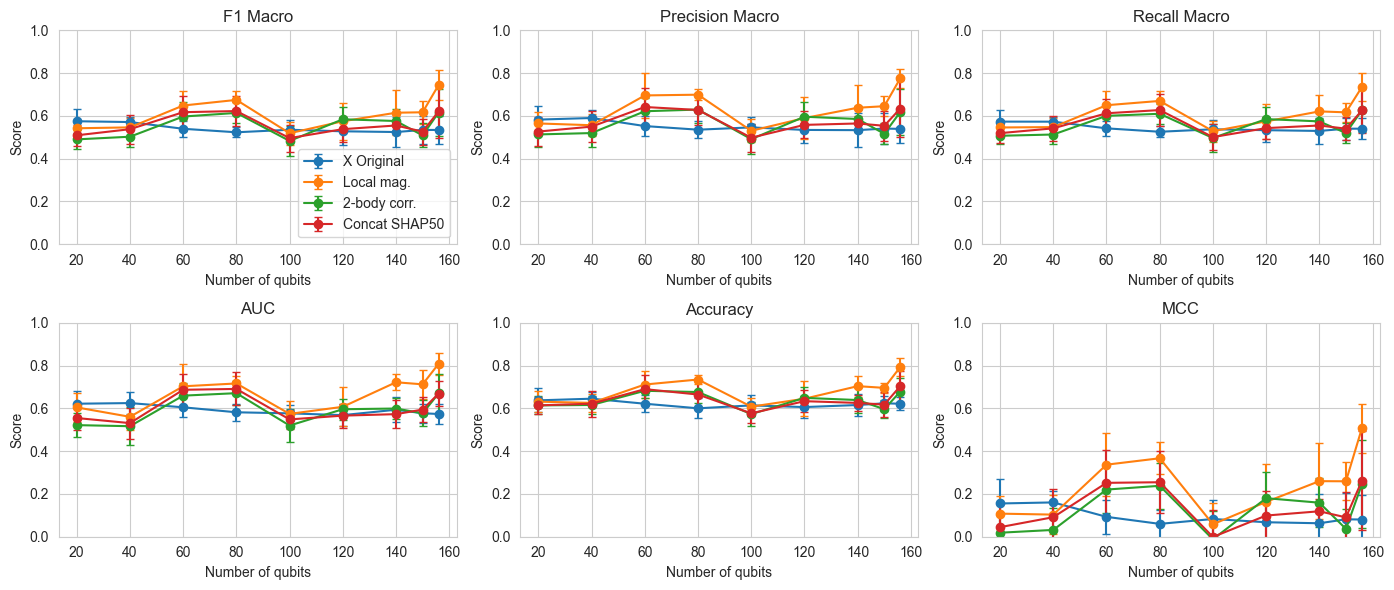

In [71]:
qubit_list = [20, 40, 60, 80, 100, 120, 140, 150, 156]
plot_metrics_vs_qubits("results_scalability", qubit_list, k_max)

 - J_ij - different computations

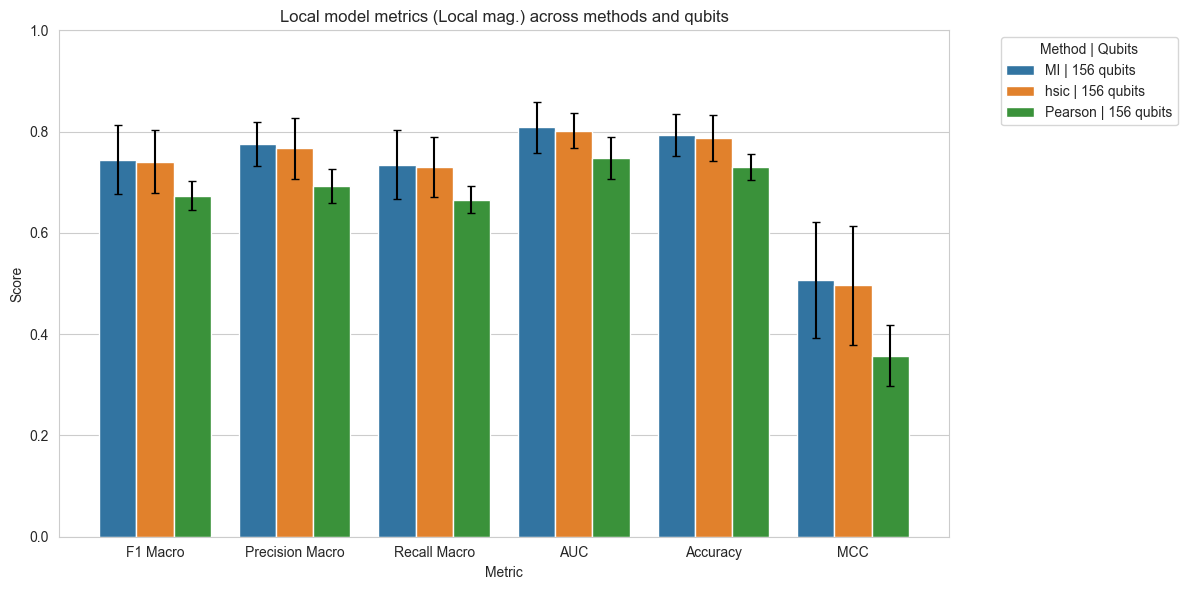

In [75]:
qubit_list = [156]
method_list = ["MI", "hsic", "Pearson"]
plot_local_metrics_bar("results_J_ij", qubit_list, method_list, tau)

 - error mitigation

Run

In [ ]:
path = "data.csv"
X_full, y_full = load_dataset(path)
if X_full is not None and y_full is not None:
    print("Dataset loaded successfully! with shape:", X_full.shape)
n_features = 100
X_c = reduce_features(X_full, y_full, n_features=n_features)
y = y_full

backend_name = (real_backend.name if hasattr(real_backend, "name") else str(real_backend))
base_folder = (f"results_optimization/{backend_name}_features_{n_features}_T_{tau}_OL_{OPTIMIZATION_LVL}_RES_{RESILIENCE_LVL}")
# MI
job_id = "d69qsnro1r9c73fmml70"
Xq_all = results_from_job_id(job_id)
save_quantum_features(X_c, Xq_all, base_folder)
classifier = "SVC"
df_all, shap_rankings_all, df_confusion = cross_validate_model(X_c, y, base_folder, classifier=classifier, n_splits=2, n_repeats=3)
plot_performance(df_all, n_features, base_folder)
shap_feature_importance(shap_rankings_all, n_features, base_folder)
plot_confusion_matrices(df_confusion, base_folder)

In [ ]:
feature_list = [20, 40, 60, 80, 100, 120, 140, 150, 156]
path = "data.csv"

# Load dataset once
X_full, y_full = load_dataset(path)

if X_full is None or y_full is None:
    raise RuntimeError("Dataset could not be loaded.")

print("Dataset loaded successfully! Shape:", X_full.shape)

backend_name = (
    real_backend.name if hasattr(real_backend, "name") else str(real_backend)
)

for n_features in feature_list:
    print(f"\n==============================")
    print(f"Running experiment for n_features = {n_features}")
    print(f"==============================")

    # ---------------------------------
    # Reduce classical features
    # ---------------------------------
    X_c = reduce_features(X_full, y_full, n_features=n_features)
    y = y_full

    # ---------------------------------
    # Base folder for this feature size
    # ---------------------------------
    base_folder = f"results_SVC/{backend_name}_features_{n_features}_T_{tau}"

    # ---------------------------------
    # Load job_id from file
    # ---------------------------------
    job_id_path = f"{base_folder}/job_id.txt"

    try:
        with open(job_id_path, "r") as f:
            job_id = f.read().strip()
    except FileNotFoundError:
        print(f"❌ job_id.txt not found for n_features={n_features}, skipping.")
        continue

    print("Loaded job_id:", job_id)

    # ---------------------------------
    # Retrieve and save quantum features
    # ---------------------------------
    Xq_all = results_from_job_id(job_id)
    save_quantum_features(X_c, Xq_all, base_folder)

    # ---------------------------------
    # Cross-validation with SVC
    # ---------------------------------
    classifier = "SVC"
    df_all, shap_rankings_all, df_confusion = cross_validate_model(
        X_c,
        y,
        base_folder,
        classifier=classifier,
        n_splits=2,
        n_repeats=3,
    )

    # ---------------------------------
    # Plots
    # ---------------------------------
    plot_performance(df_all, n_features, base_folder)
    shap_feature_importance(shap_rankings_all, n_features, base_folder)
    plot_confusion_matrices(df_confusion, base_folder)

print("\n✅ All experiments finished.")


# 4. Tensor networks

As we are only able to simulate on our classical devices circuits with maximally ~20 qubits and furthermore only ~10 while using noise. We are unable to provide useful comparison for our results in this way. Thus, we utilize tensor networks, which in theory, should be able to approximate final circuit for bigger number of qubits. 

# 5. Comparison with state of the art deep learning methods